In [1]:
%pip install numpy matplotlib scipy

  Using cached matplotlib-3.10.8-cp312-cp312-macosx_11_0_arm64.whl.metadata (52 kB)
  Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl.metadata (5.5 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
  Using cached pillow-12.1.1-cp312-cp312-macosx_11_0_arm64.whl.metadata (8.8 kB)
  Using cached pyparsing-3.3.2-py3-none-any.whl.metadata (5.8 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.2/5.2 MB 39.8 MB/s  0:00:00
Using cached matplotlib-3.10.8-cp312-cp312-macosx_11_0_arm64.whl (8.1 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.3/20.3 MB 49.4 MB/s  0:00:00m0:00:0100:01
Using cached contourpy-1.3.3-cp312-cp312-macosx_11_0_arm64.whl (273 kB)
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.9/2.9 MB 11.1 MB/s  0:00:00eta 0:00:01
Using cached pillow-12.1.1-cp312-cp312-macosx_11_0_arm64.whl (4.7 MB)
Using cached pyparsing-3.3.2-py3-none-any.whl (122 kB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9/9 [m

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import truncnorm

SEED = 42
K = 10

HORIZONS_PART1 = [100, 1000, 10000]
NUM_SIMS_PART1 = 50

N_PART2 = 2_000
DELTAS = [0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
NUM_SIMS_PART2 = 10
MU_OPTIMAL = 1.2
MU_REST = -1.2

In [31]:
def thompson_sampling_gaussian(mu, n, rng):
    num_arms = len(mu)
    mu_star = np.max(mu)

    counts = np.zeros(num_arms)
    sum_rewards = np.zeros(num_arms)

    cumulative_regret = np.zeros(n)
    running_regret = 0.0

    for t in range(n):
        #posterior params
        precision = 1.0 + counts
        mu_post = sum_rewards / precision
        sigma_post = 1.0 / np.sqrt(precision)

        #sample from posterior and pick best arm
        theta = rng.normal(mu_post, sigma_post)
        arm = np.argmax(theta)

        #pull arm
        reward = rng.normal(mu[arm], 1.0)
        counts[arm] += 1
        sum_rewards[arm] += reward

        running_regret += mu_star - mu[arm]
        cumulative_regret[t] = running_regret

    return cumulative_regret

In [33]:
def thompson_sampling_uniform(mu, n, rng):
    num_arms = len(mu)
    mu_star = np.max(mu)

    counts = np.zeros(num_arms)
    sum_rewards = np.zeros(num_arms)

    #counts = 

    cumulative_regret = np.zeros(n)
    running_regret = 0.0

    for t in range(n):
        theta = np.empty(num_arms)
        for k in range(num_arms):
            if counts[k] == 0:
                theta[k] = rng.uniform(-1.0, 1.0)
            else:
                x_bar = sum_rewards[k] / counts[k]
                sigma = 1.0 / np.sqrt(counts[k])
                
                a_std = (-1.0 - x_bar) / sigma
                b_std = (1.0 - x_bar) / sigma
                theta[k] = truncnorm.rvs(a_std, b_std, loc=x_bar, scale=sigma, random_state=rng)


        arm = np.argmax(theta)
        reward = rng.normal(mu[arm], 1.0)
        counts[arm] += 1
        sum_rewards[arm] += reward

        running_regret += mu_star - mu[arm]
        cumulative_regret[t] = running_regret

    return cumulative_regret

In [35]:
def ucb(mu, n, rng):
    num_arms = len(mu)
    mu_star = np.max(mu)

    counts = np.zeros(num_arms)
    sum_rewards = np.zeros(num_arms)

    cumulative_regret = np.zeros(n)
    running_regret = 0.0

    for t in range(n):
        #init 
        if t < num_arms:
            arm = t
        else:
            x_bar = sum_rewards / counts
            bonus = np.sqrt(2.0 * np.log(t + 1) / counts) # ----double check
            arm = np.argmax(x_bar + bonus)

        reward = rng.normal(mu[arm], 1.0)
        counts[arm] += 1
        sum_rewards[arm] += reward

        running_regret += mu_star - mu[arm]
        cumulative_regret[t] = running_regret

    return cumulative_regret

# Bayesian regret TS

In [ ]:
def run_bayesian_regret(algorithm_fn, horizons, num_sims, seed):
    #this runs both TS variants
    master_rng = np.random.default_rng(seed)
    results = {}

    for n in horizons:
        final_regrets = np.empty(num_sims)
        for sim in range(num_sims):
            sim_rng = np.random.default_rng(master_rng.integers(0, 2**31))
            mu = sim_rng.standard_normal(K)
            regret_curve = algorithm_fn(mu, n, sim_rng)
            final_regrets[sim] = regret_curve[-1]

        results[n] = (np.mean(final_regrets), np.std(final_regrets) / np.sqrt(num_sims))
    return results


print("well specified TS")
results_wellspec = run_bayesian_regret(
    thompson_sampling_gaussian, HORIZONS_PART1, NUM_SIMS_PART1, seed=SEED
)
print("misspecified TS")
results_misspec = run_bayesian_regret(
    thompson_sampling_uniform, HORIZONS_PART1, NUM_SIMS_PART1, seed=SEED
)

for label, res in [("well specified", results_wellspec), ("misspecified", results_misspec)]:
    print(f"\n{label}:")
    for n, (mean, se) in sorted(res.items()):
        print(f"  n={n}  Bayesian Regret = {mean:.2f} +- {se:.2f}")

well specified TS
misspecified TS

well specified:
  n=100  Bayesian Regret = 36.64 +- 1.37
  n=1000  Bayesian Regret = 61.26 +- 2.83
  n=10000  Bayesian Regret = 112.84 +- 10.99

misspecified:
  n=100  Bayesian Regret = 43.68 +- 2.37
  n=1000  Bayesian Regret = 119.43 +- 18.59
  n=10000  Bayesian Regret = 153.27 +- 32.38


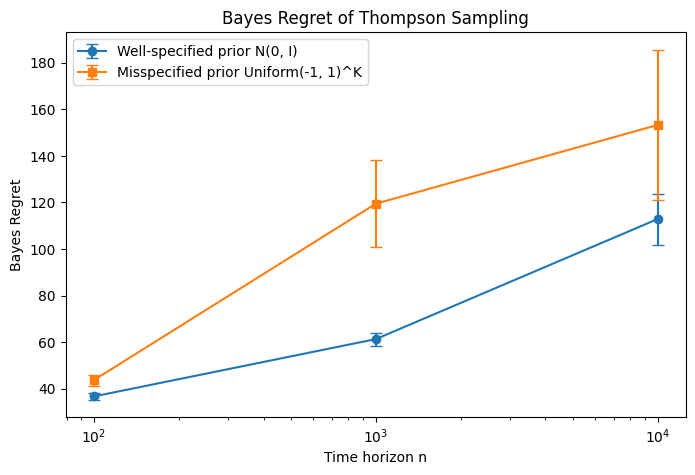

In [15]:
horizons = sorted(HORIZONS_PART1)
means_ws = [results_wellspec[n][0] for n in horizons]
ses_ws   = [results_wellspec[n][1] for n in horizons]
means_ms = [results_misspec[n][0]  for n in horizons]
ses_ms   = [results_misspec[n][1]  for n in horizons]

fig, ax = plt.subplots(figsize=(8, 5))
ax.errorbar(horizons, means_ws, yerr=ses_ws, marker='o', capsize=4,
            label='Well-specified prior N(0, I)')
ax.errorbar(horizons, means_ms, yerr=ses_ms, marker='s', capsize=4,
            label='Misspecified prior Uniform(-1, 1)^K')
ax.set_xscale('log')
ax.set_xlabel('Time horizon n')
ax.set_ylabel('Bayes Regret')
ax.set_title('Bayes Regret of Thompson Sampling')
ax.legend()
plt.show()

Obviously the well specified prior is consistently better than the bad prior. It is somewhat competitive even still though since it is still eventually converging to the best arms just like the well specified ones, it just started at a disadvantage (that becomes very punishing at 10^3)

The posterior sampling rule for the well specified case is easy, since it is still gaussian so you're still sampling from normal and picking argmax

for the misspecified its more complicated because you have to clamp to just the unif range of -1, 1 which hurts the model by making it hard to compare arms that are very good since they get pushed against the ceiling.

In [22]:
# freq regret --------------------------------

def make_mu_vector(delta):
    mu = np.full(K, MU_REST)
    mu[0] = MU_OPTIMAL
    mu[1] = MU_OPTIMAL - delta
    return mu


def run_frequentist_experiment(algorithm_fn, delta, n, num_sims, seed):
    mu = make_mu_vector(delta)
    master_rng = np.random.default_rng(seed)
    final_regrets = np.empty(num_sims)

    for sim in range(num_sims):
        sim_rng = np.random.default_rng(master_rng.integers(0, 2**31))
        regret_curve = algorithm_fn(mu, n, sim_rng)
        final_regrets[sim] = regret_curve[-1]

    return np.mean(final_regrets), np.std(final_regrets) / np.sqrt(num_sims)


algorithms = {
    'UCB': ucb,
    'Thompson Sampling': thompson_sampling_gaussian,
}

part2_results = {}
for name, fn in algorithms.items():
    print("debug")
    means, ses = [], []
    for delta in DELTAS:
        avg_reg, se = run_frequentist_experiment(fn, delta, N_PART2, NUM_SIMS_PART2, seed=SEED)
        means.append(avg_reg)
        ses.append(se)
    part2_results[name] = (means, ses)

for name, (means, ses) in part2_results.items():
    print(f"\n{name}:")
    for delta, m, s in zip(DELTAS, means, ses):
        print(f"  delta={delta:.2f}  Regret = {m:.2f} +- {s:.2f}")

debug
debug

UCB:
  delta=0.05  Regret = 94.10 +- 3.99
  delta=0.10  Regret = 109.43 +- 7.37
  delta=0.20  Regret = 101.72 +- 6.50
  delta=0.30  Regret = 94.41 +- 7.28
  delta=0.40  Regret = 88.08 +- 3.02
  delta=0.50  Regret = 89.30 +- 4.41
  delta=0.60  Regret = 82.74 +- 3.90
  delta=0.70  Regret = 83.19 +- 3.97
  delta=0.80  Regret = 80.48 +- 4.05
  delta=0.90  Regret = 81.57 +- 3.27
  delta=1.00  Regret = 74.30 +- 2.37

Thompson Sampling:
  delta=0.05  Regret = 69.96 +- 5.73
  delta=0.10  Regret = 96.46 +- 18.04
  delta=0.20  Regret = 91.58 +- 23.34
  delta=0.30  Regret = 85.11 +- 15.79
  delta=0.40  Regret = 68.80 +- 4.98
  delta=0.50  Regret = 64.67 +- 4.05
  delta=0.60  Regret = 63.54 +- 2.91
  delta=0.70  Regret = 60.74 +- 2.58
  delta=0.80  Regret = 61.20 +- 2.41
  delta=0.90  Regret = 58.86 +- 2.07
  delta=1.00  Regret = 59.56 +- 2.16


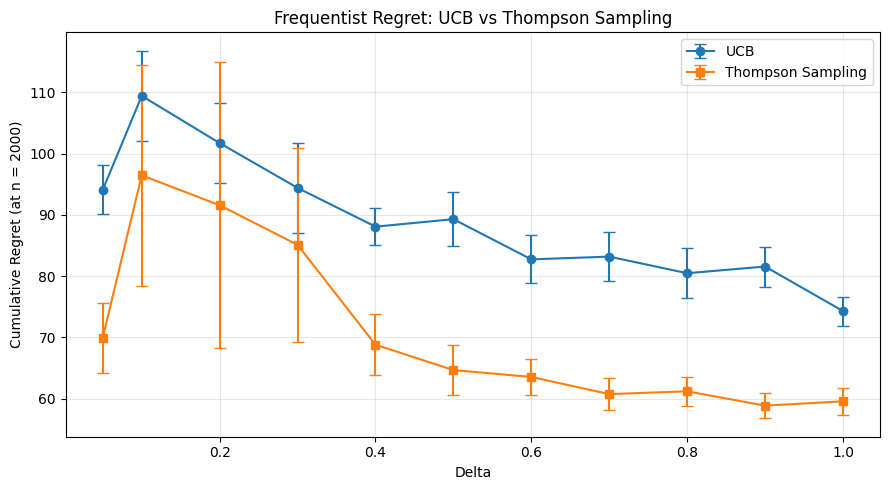

In [25]:
fig, ax = plt.subplots(figsize=(9, 5))
markers = {'UCB': 'o', 'Thompson Sampling': 's'}

for name, (means, ses) in part2_results.items():
    ax.errorbar(DELTAS, means, yerr=ses, marker=markers[name], capsize=4, label=name)

ax.set_xlabel('Delta')
ax.set_ylabel('Cumulative Regret (at n = 2000)')
ax.set_title('Frequentist Regret: UCB vs Thompson Sampling')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

as can be seen, Thompson is consistently better than UCB, especially as delta increases. At small gaps however, Thompson sampling has much wider standard error compared to UCB which seems like the price you likely pay for having a more eager exploration than UCB.

The gap is somewhat steady, especially between 0.4 and 1.0. at lower deltas they are a bit close and TS has very high error. At high delta TS doesn't decrease much at all, which should be because it is forced to explore all the non optimal arms. UCB does this too, but its far enough behind that it is still benefitting from the larger gaps.